## Contributor: Amna Rauf 

## Data Cleaning for Overdose Data

1. Loading Dataset:

In [341]:
import pandas as pd
import numpy as np

pd.set_option("mode.copy_on_write", True)

overdose_list = (
    []
)  # initializing a list all_overdose_data to store data from each year (2006 to 2014)
for i in range(2006, 2015):
    over_dose_data = pd.read_csv(
        f"https://github.com/nickeubank/ids540_opioid_data/raw/refs/heads/main/vitalstatistics/Underlying%20Cause%20of%20Death,%20{i}.txt",
        delimiter="\t",
    )
    overdose_list.append(over_dose_data)  # Appending each year's dataframe to the list
overall_overdose_df = pd.concat(overdose_list)  # cancatenate
# overall_overdose_df

2. Exploring the data:

In [342]:
# Getting a sense of the data
# overall_overdose_df.sample(20)

In [343]:
# Making sure the years are filtered to our study window i.e. 2006 to 2014
overall_overdose_df["Year"].value_counts()
print(f"The years have been filtered to 2006 to 2014")

The years have been filtered to 2006 to 2014


In [344]:
# Getting a sense of column types
data_types = overall_overdose_df[
    [
        "County",
        "Drug/Alcohol Induced Cause",
        "County Code",
        "Year",
        "Year Code",
        "Deaths",
    ]
].dtypes
print(data_types)

County                         object
Drug/Alcohol Induced Cause     object
County Code                   float64
Year                          float64
Year Code                     float64
Deaths                        float64
dtype: object


Initial few issues that need correction:
1. The numerical variables including County Code, Year, Deaths and Year Code are floating point integers. Needs to be changed.
2. Have to filter the Data to our treatment and Control states: Florida & Nevada, Colorado, North Carolina and Wisconsin.

3. Data Cleaning

In [345]:
# Change Data types from float to integers for cleaning:
overall_overdose_df["Deaths"] = overall_overdose_df["Deaths"].astype("Int64")
overall_overdose_df["Year"] = overall_overdose_df["Year"].astype("Int64")
overall_overdose_df["Year Code"] = overall_overdose_df["Year Code"].astype("Int64")
overall_overdose_df["County Code"] = overall_overdose_df["County Code"].astype("Int64")

In [346]:
# Filter for treatment and control states by FIPS Codes:

# Convert County Code to string
overall_overdose_df["County Code"] = (
    overall_overdose_df["County Code"].astype(str).str.zfill(5)
)  # leading 0s disappeared from Colorado when we converted county code to integers from floating point to integers earlier on,
# so adding leading 0s to make sure county codes has a total of 5 characters

# Createing a boolean mask to identify rows where County Code starts with our states of interest:
filtered_states = (
    overall_overdose_df["County Code"].str.startswith("12")  # Florida
    | overall_overdose_df["County Code"].str.startswith("37")  # North Carolina
    | overall_overdose_df["County Code"].str.startswith("55")  # Wisconsin
    | overall_overdose_df["County Code"].str.startswith("32")  # Nevada
    | overall_overdose_df["County Code"].str.startswith("08")  # Colorado
)
# Apply the mask to filter the DataFrame to only include rows from the five states
filtered_states_df = overall_overdose_df[filtered_states]
filtered_states_df

# Confirming the 5 states:
unique_filtered_counties = filtered_states_df["County Code"].str[:2].unique()
print(f"County codes present in the filtered dataframe: {unique_filtered_counties}")
# filtered_states_df

County codes present in the filtered dataframe: ['08' '12' '32' '37' '55']


In [347]:
# List all unique Colorado county FIPS codes (now County Code is string with 5 chars)
filtered_states_df[filtered_states_df["County Code"].str.startswith("08")][
    "County Code"
].unique()

array(['08001', '08003', '08005', '08007', '08009', '08011', '08013',
       '08014', '08015', '08017', '08019', '08021', '08023', '08025',
       '08027', '08029', '08031', '08033', '08035', '08037', '08039',
       '08041', '08043', '08045', '08047', '08049', '08051', '08055',
       '08057', '08059', '08061', '08063', '08065', '08067', '08069',
       '08071', '08073', '08075', '08077', '08081', '08083', '08085',
       '08087', '08089', '08091', '08093', '08095', '08097', '08099',
       '08101', '08103', '08105', '08107', '08109', '08113', '08115',
       '08117', '08119', '08121', '08123', '08125'], dtype=object)

Colorado is missing 3 counties.

In [348]:
# Creating a temporary column that flags D1 and D2 deaths
# If the cause code is D1 or D2, put the death count, otherwise put 0
filtered_states_df["_d1and2_flagged"] = np.where(
    filtered_states_df["Drug/Alcohol Induced Cause Code"].isin(
        ["D1", "D2"]
    ),  # Check if cause is D1 or D2
    filtered_states_df["Deaths"],  # If yes, use the actual death count
    0,  # If no, use 0
)

# Calculate total D1+D2 deaths for each county-year combination
# and add that total to every row within that county-year group
filtered_states_df["D1and2_Deaths"] = filtered_states_df.groupby(
    ["County Code", "Year"]
)[  # Group by county and year
    "_d1and2_flagged"
].transform(  # Look at only the flagged deaths column
    "sum"
)  # Sum within each group, but keep all rows

# Remove the temporary column
filtered_states_df = filtered_states_df.drop(columns=["_d1and2_flagged"])

# sanity check
print(
    "Sample D1+D2 totals:",
    filtered_states_df[
        ["County Code", "Year", "D1and2_Deaths"]
    ]  # Select relevant columns
    .drop_duplicates()  # Remove duplicate county-year rows
    .head(),
)  # Show first 5

# filtered_states_df

Sample D1+D2 totals:     County Code  Year  D1and2_Deaths
387       08001  2006             62
391       08003  2006              0
392       08005  2006             66
396       08007  2006              0
397       08009  2006              0


In [349]:
# Creating a version with one row per county year
# Create a temporary column that flags D1 and D2 deaths
filtered_states_df["_d12_flagged"] = np.where(
    filtered_states_df["Drug/Alcohol Induced Cause Code"].isin(
        ["D1", "D2"]
    ),  # Check if D1 or D2
    filtered_states_df["Deaths"],  # Use death count if yes
    0,  # Use 0 if no
)

# Collapse the data to ONE row per county-year
# This aggregates all cause codes into a single summary row
filtered_states_df = filtered_states_df.groupby(
    ["County Code", "Year"], as_index=False
).agg(  # Group by county + year, keep as columns
    D1andD2_Deaths=("_d12_flagged", "sum"),  # Sum all D1+D2 flagged deaths in the group
    County=("County", "first"),  # Take the county name (same for all rows in group)
    Total_Deaths=("Deaths", "sum"),  # sum ALL deaths across all causes
)

# Sort by county code and year
filtered_states_df = filtered_states_df.sort_values(
    ["County Code", "Year"]
).reset_index(drop=True)


# filtered_states_df

In [350]:
# Split County column to extract county name and state
filtered_states_df[["County", "State"]] = filtered_states_df["County"].str.split(
    ", ", expand=True
)

# Clean up whitespace incase there is any by using strip command
filtered_states_df["County"] = filtered_states_df["County"].str.strip()
filtered_states_df["State"] = filtered_states_df["State"].str.strip()

# filtered_states_df[["Year", "State", "County", "County Code", "D1andD2_Deaths"]].head()

4. Exploring trends of drug overdose mortality in the treatment and control states:

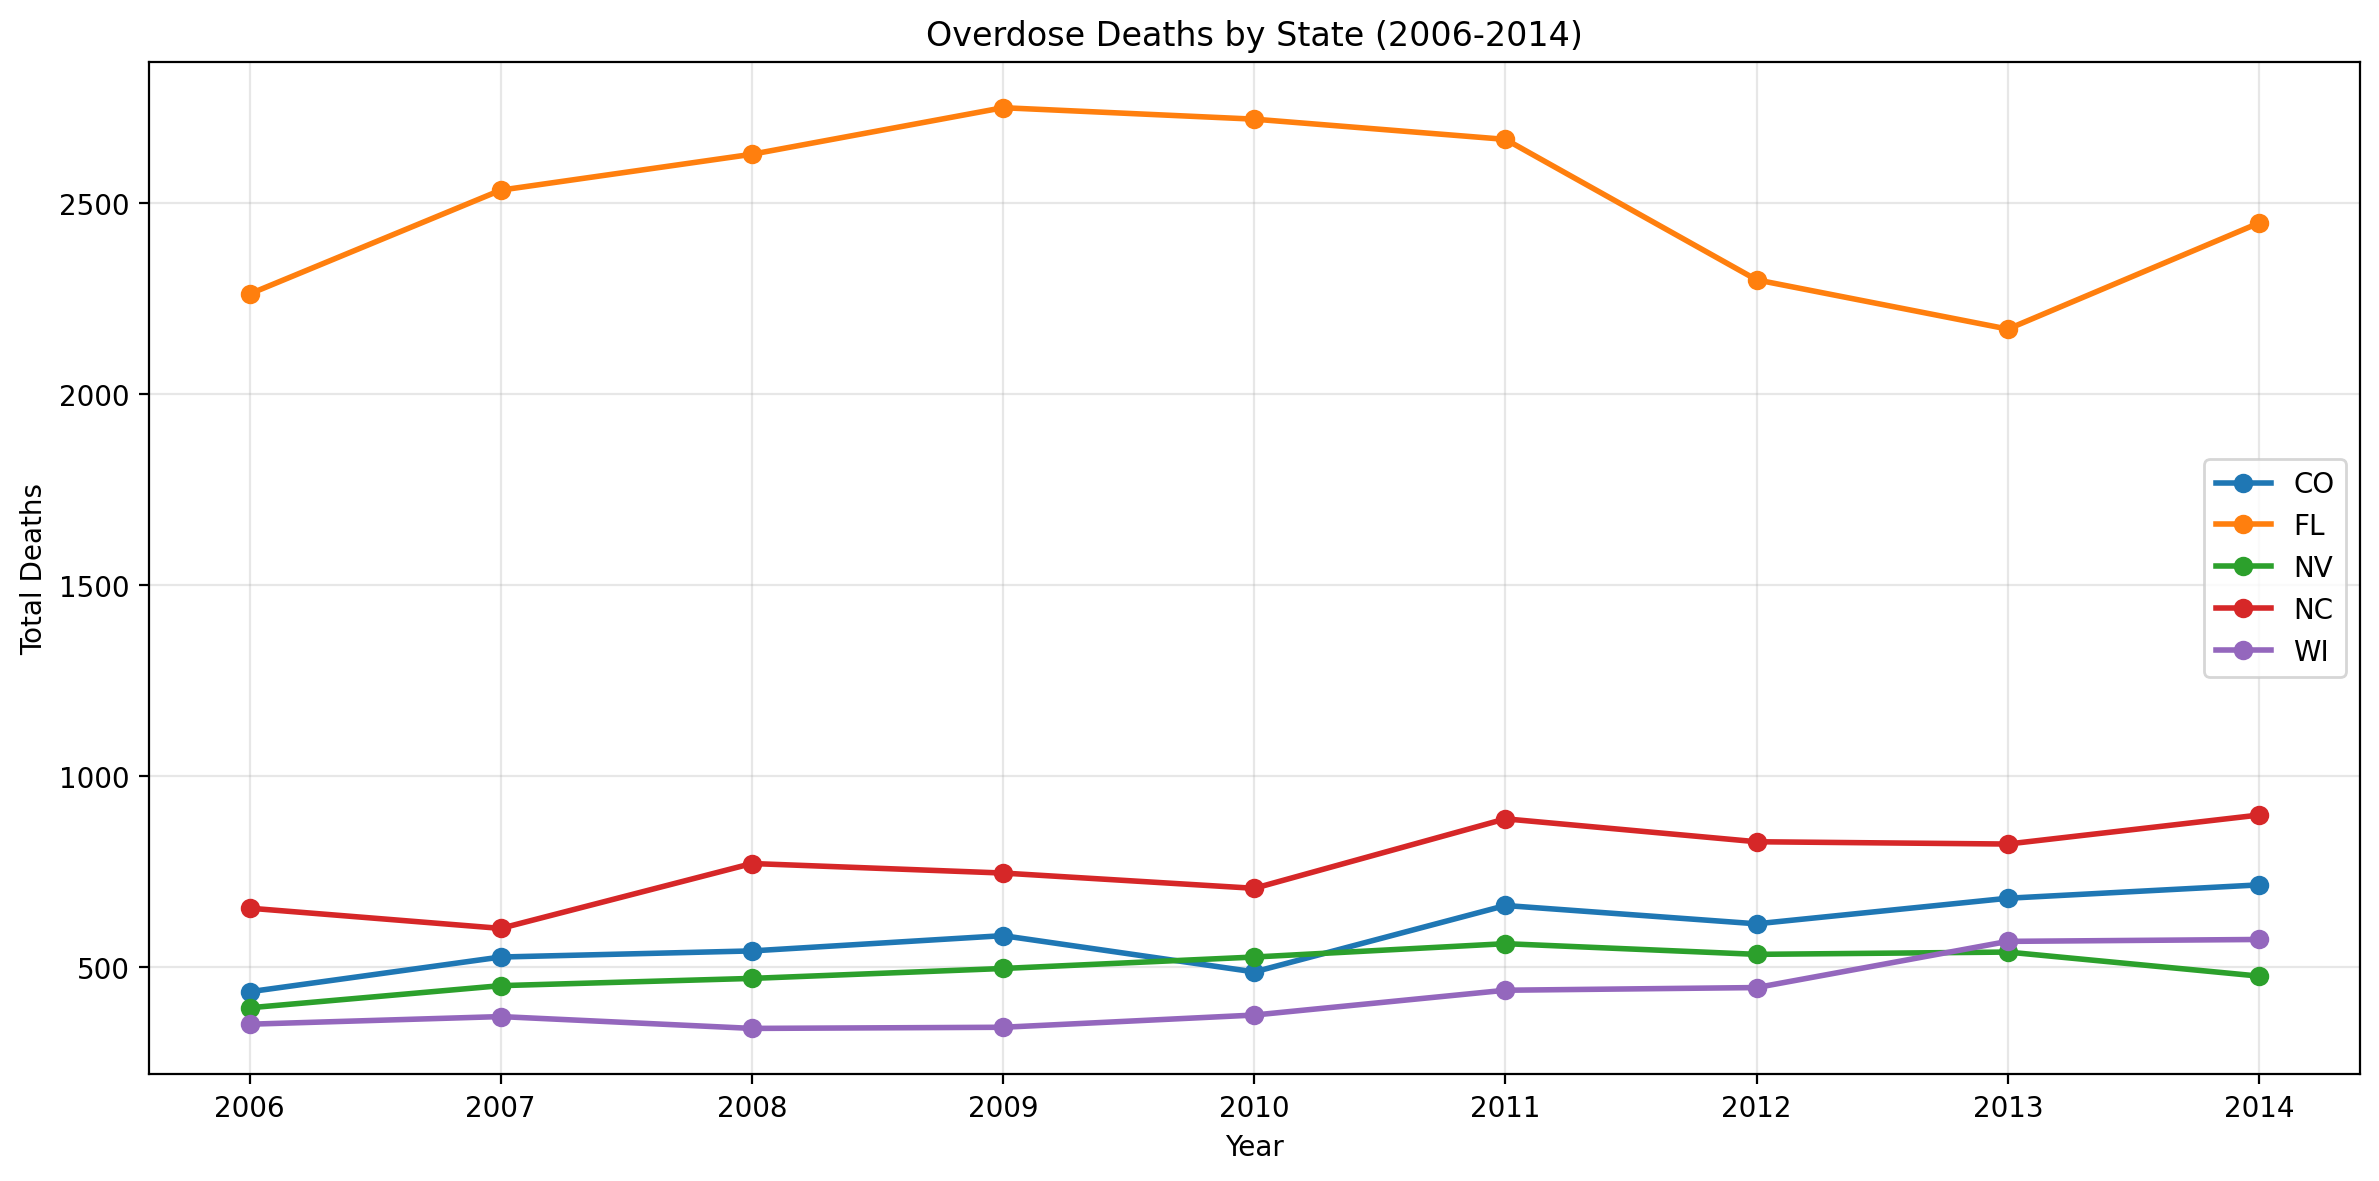

In [351]:
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")

# Aggregate by state and year
state_yearly = (
    filtered_states_df.groupby(["State", "Year"])["D1andD2_Deaths"].sum().reset_index()
)

# Plot each state
fig, ax = plt.subplots(figsize=(12, 6))

for state in filtered_states_df["State"].unique():
    state_data = state_yearly[state_yearly["State"] == state]
    ax.plot(
        state_data["Year"],
        state_data["D1andD2_Deaths"],
        marker="o",
        linewidth=2,
        label=state,
    )

ax.set_xlabel("Year")
ax.set_ylabel("Total Deaths")
ax.set_title("Overdose Deaths by State (2006-2014)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [352]:
# Select and reorder columns
final_df = filtered_states_df[
    ["State", "County", "County Code", "Year", "D1andD2_Deaths"]
].reset_index(
    drop=True
)  # resetting the index

# View the result
# final_df.head()
# final_df

In [353]:
# Counting the number of counties in each state
county_counts = final_df.groupby("State")["County"].nunique()
print(county_counts)

State
CO     61
FL     67
NC    100
NV     17
WI     72
Name: County, dtype: int64


There are no missing counties except for Colorado which has 3 missing counties.

MERGE with Population Data

I want to rename "county code" into FIPS for easier merging.

In [354]:
final_df = final_df.rename(
    columns={
        "County Code": "FIPS",
        "County": "CTYNAME",
        "D1andD2_Deaths": "Overdose Deaths",
    }
)

# final_df

In [355]:
import pandas as pd

pd.set_option("mode.copy_on_write", True)

population2000 = pd.read_csv(
    "https://www2.census.gov/programs-surveys/popest/datasets/2000-2010/intercensal/county/co-est00int-tot.csv",
    encoding="latin1",  # handle non-UTF-8 bytes
    sep=",",  # file is a CSV
    engine="python",
)

population2010 = pd.read_csv(
    "https://www2.census.gov/programs-surveys/popest/datasets/2010-2019/counties/totals/co-est2019-alldata.csv",
    encoding="latin1",  # handle non-UTF-8 bytes
    sep=",",  # file is a CSV
    engine="python",
)

population2000.sample(5)


population2010 = population2010.drop("POPESTIMATE2010", axis=1)


five_states_population2000 = population2000[
    population2000["STNAME"].isin(
        ["Florida", "Colorado", "Nevada", "North Carolina", "Wisconsin"]
    )
]


five_states_population2010 = population2010[
    population2010["STNAME"].isin(
        ["Florida", "Colorado", "Nevada", "North Carolina", "Wisconsin"]
    )
]


population_concat = pd.concat([five_states_population2000, five_states_population2010])

population_concat


count_Colorado = (population_concat["STNAME"] == "Colorado").sum()
count_Florida = (population_concat["STNAME"] == "Florida").sum()
count_Nevada = (population_concat["STNAME"] == "Nevada").sum()
count_North_Carolina = (population_concat["STNAME"] == "North Carolina").sum()
count_Wisconsin = (population_concat["STNAME"] == "Wisconsin").sum()

count_Colorado, count_Florida, count_Nevada, count_North_Carolina, count_Wisconsin


population_concat["STATE"] = population_concat["STATE"].astype(str).str.zfill(2)

population_concat["COUNTY"] = population_concat["COUNTY"].astype(str).str.zfill(3)

population_concat["FIPS"] = population_concat["STATE"] + population_concat["COUNTY"]

population_concat["FIPS"].dtype

population_concat


population_melted = pd.melt(
    population_concat,
    id_vars=["FIPS", "STNAME", "CTYNAME"],
    value_vars=[
        "POPESTIMATE2006",
        "POPESTIMATE2007",
        "POPESTIMATE2008",
        "POPESTIMATE2009",
        "POPESTIMATE2010",
        "POPESTIMATE2011",
        "POPESTIMATE2012",
        "POPESTIMATE2013",
        "POPESTIMATE2014",
    ],
)
population_melted


population_melted_no_na = population_melted.dropna(subset=population_melted.columns[-1])

# population_melted_no_na

/var/folders/nz/klsby37n713_4fz64n23y_hw0000gn/T/ipykernel_8495/1381906339.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  population_concat["FIPS"] = population_concat["STATE"] + population_concat["COUNTY"]


In [356]:
# Counting the number of counties in each state in the population data
county_counts_pop_data = population_melted_no_na.groupby("STNAME")["FIPS"].nunique()
print(county_counts_pop_data)

STNAME
Colorado           65
Florida            68
Nevada             18
North Carolina    101
Wisconsin          73
Name: FIPS, dtype: int64


In [357]:
population_melted_no_na["Year"] = 1
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2006", "Year"
] = 2006
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2007", "Year"
] = 2007
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2008", "Year"
] = 2008
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2009", "Year"
] = 2009
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2010", "Year"
] = 2010
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2011", "Year"
] = 2011
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2012", "Year"
] = 2012
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2013", "Year"
] = 2013
population_melted_no_na.loc[
    population_melted_no_na["variable"] == "POPESTIMATE2014", "Year"
] = 2014

population_melted_no_na.rename(columns={"value": "Population"}, inplace=True)

# population_melted_no_na

Even though this shows that Nevada has 17 counties in the Overdose dataset, it is holds true except for the year 2006 where it has 2 missing counties both: 32000 and 32011.

In [358]:
pop_overdose_merged = pd.merge(
    population_melted_no_na, final_df, how="left", on=["FIPS", "CTYNAME", "Year"]
)

# pop_overdose_merged

In [359]:
# renaming 'D1andD2_Deaths' to 'Overdose Deaths'

pop_overdose_merged = pop_overdose_merged.rename(
    columns={"D1andD2_Deaths": "Overdose Deaths"}
)
# pop_overdose_merged

For next steps, we will drop the counties where populations are less than 350,000.

In [360]:
# checking data type for population
print(pop_overdose_merged.Population.dtype)

float64


In [361]:
# Drop counties with population less than 350,000
pop_overdose_merged_sel_counties = pop_overdose_merged[
    pop_overdose_merged["Population"] >= 350000
]

# Check the result
print(f"Number of rows before filtering: {len(pop_overdose_merged)}")
print(f"Number of rows after filtering: {len(pop_overdose_merged_sel_counties)}")


# pop_overdose_merged_sel_counties

Number of rows before filtering: 2925
Number of rows after filtering: 294


Dropping codes that are state level codes like 08000 or 55000 for Wisconsin as these are state level population estimates which is why we have missing overdose data for them.

In [362]:
# checking data type for FIPS
print(pop_overdose_merged_sel_counties.FIPS.dtype)

object


In [363]:
# dropping counties with three trailing 0s (state codes)
pop_overdose_merged_sel_counties = pop_overdose_merged_sel_counties[
    ~pop_overdose_merged_sel_counties["FIPS"].str.endswith("000")
]

print(
    f"Number of rows after removing state state codes: {len(pop_overdose_merged_sel_counties)}"
)
# pop_overdose_merged_sel_counties

Number of rows after removing state state codes: 249


No more missing data in our merged dataset of population and overdose data after dropping state codes and populations less than 350,000.

Calculation of overdose mortality:

In [ ]:
# Calculate mortality rate for each county (per 100,000 population)
pop_overdose_merged_sel_counties["County_Mortality_Rate"] = (
    pop_overdose_merged_sel_counties["Overdose Deaths"]
    / pop_overdose_merged_sel_counties["Population"]
) * 100000

# Aggregate to state level by summing deaths and populations
state_mortality = (
    pop_overdose_merged_sel_counties.groupby(["STNAME", "Year"])
    .agg({"Overdose Deaths": "sum", "Population": "sum"})
    .reset_index()
)

# Calculate state mortality rate
state_mortality["State_Mortality_Rate"] = (
    state_mortality["Overdose Deaths"] / state_mortality["Population"]
) * 100000

print("State-level mortality rates:")
# print(state_mortality)
# state_mortality

State-level mortality rates:


In [365]:
# adding state level mortality in the pop_overdose_merged_sel_counties as well:

pop_overdose_merged_sel_counties = pop_overdose_merged_sel_counties.merge(
    state_mortality[["STNAME", "Year", "State_Mortality_Rate"]],
    on=["STNAME", "Year"],
    how="left",
)
# pop_overdose_merged_sel_counties

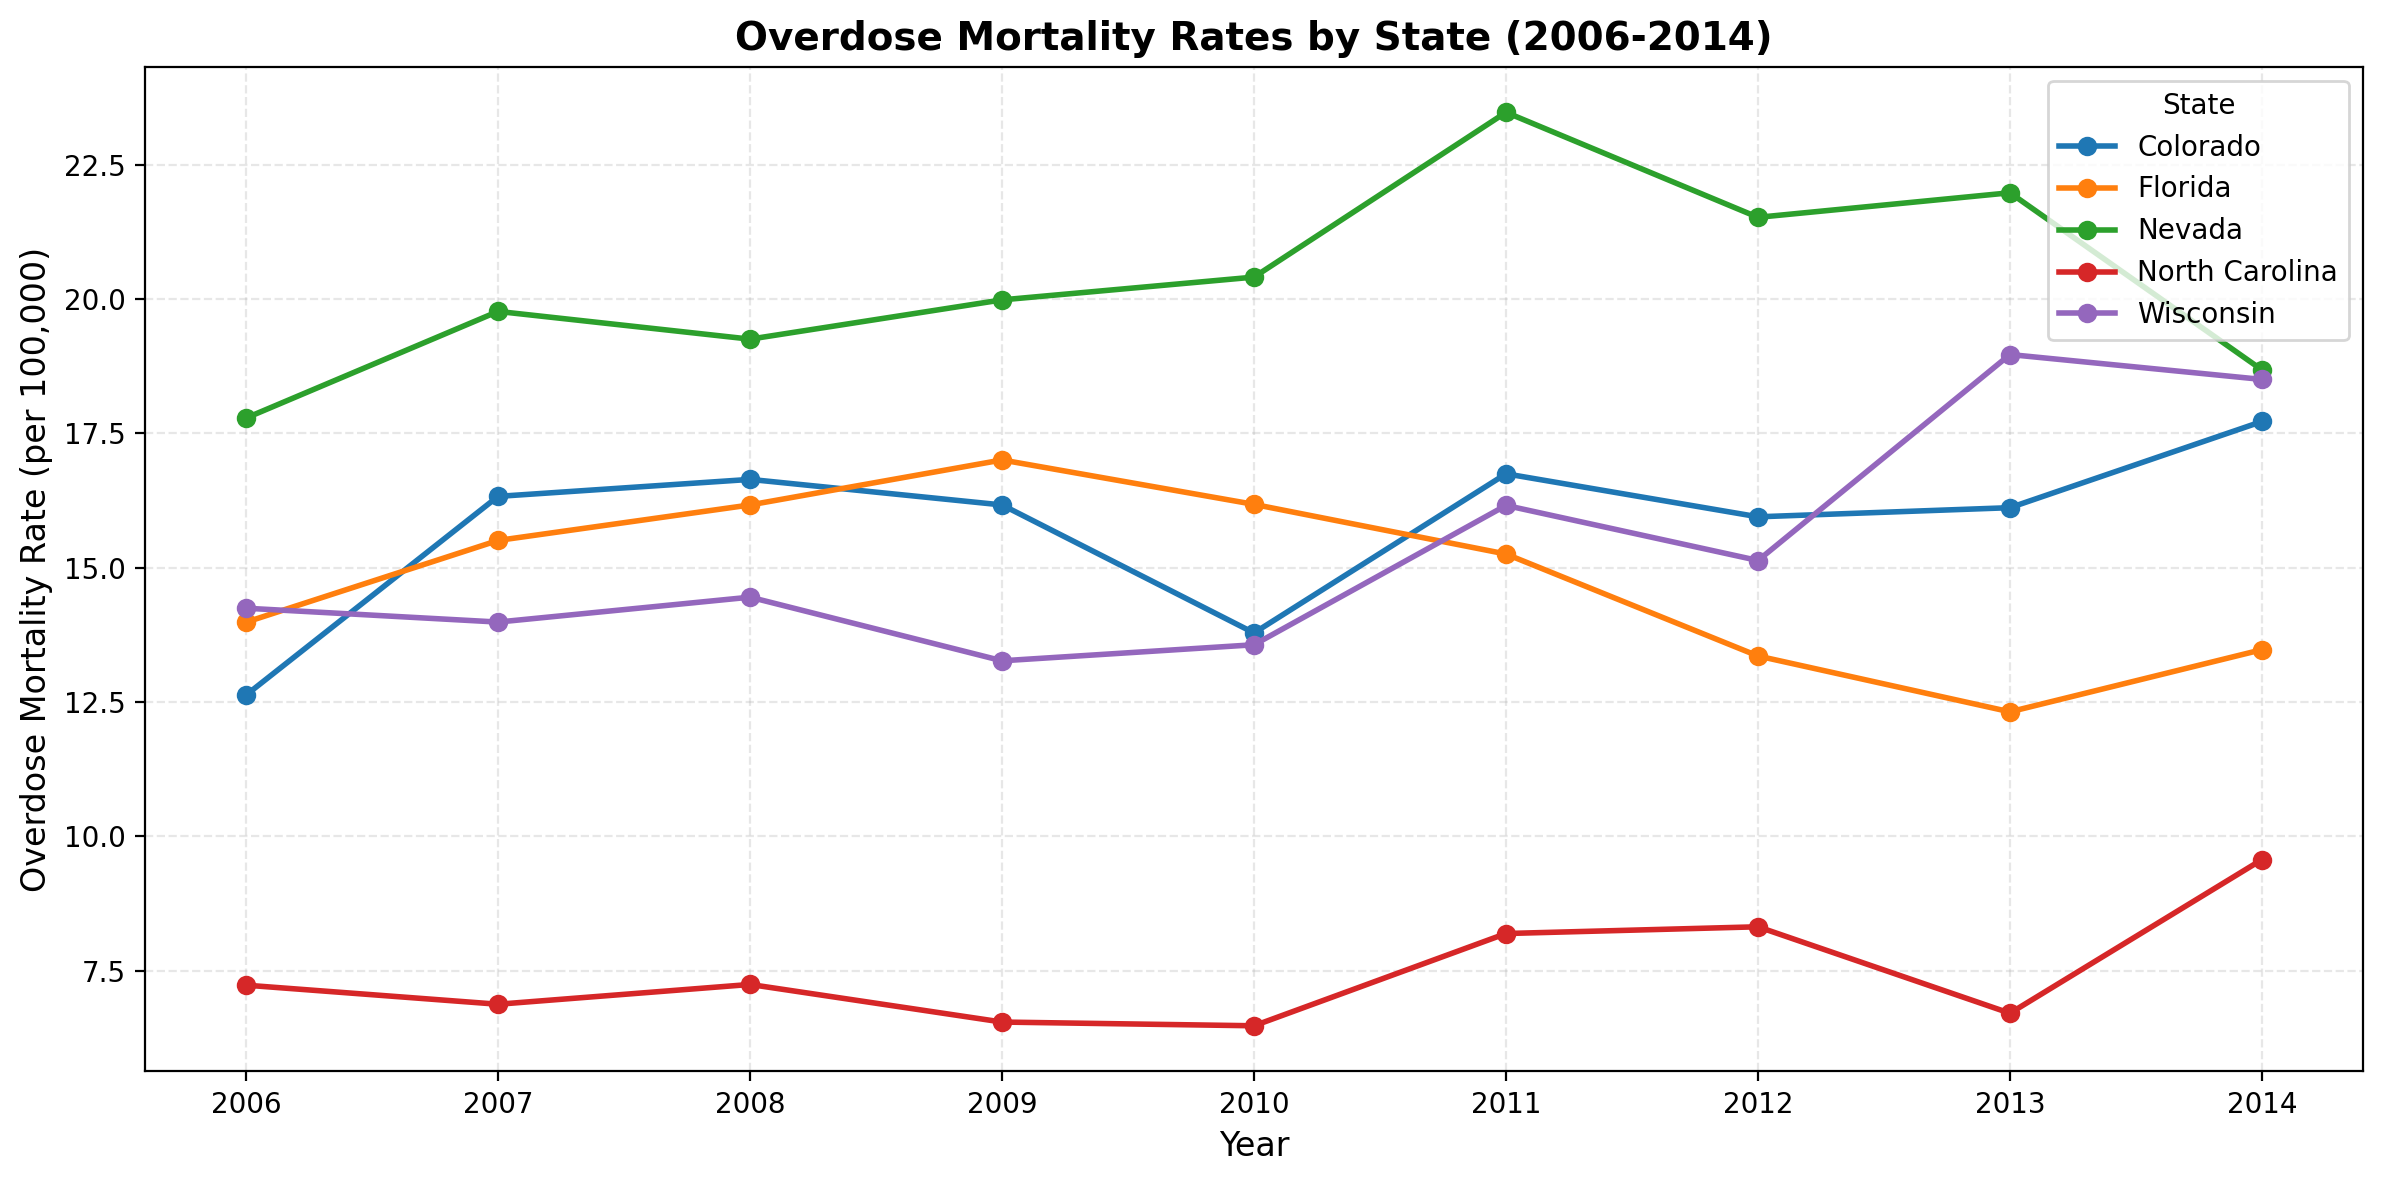

In [366]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for state in state_mortality["STNAME"].unique():
    state_data = state_mortality[state_mortality["STNAME"] == state]
    plt.plot(
        state_data["Year"],
        state_data["State_Mortality_Rate"],
        marker="o",
        label=state,
        linewidth=2,
        markersize=6,
    )

plt.xlabel("Year", fontsize=12)
plt.ylabel("Overdose Mortality Rate (per 100,000)", fontsize=12)
plt.title(
    "Overdose Mortality Rates by State (2006-2014)", fontsize=14, fontweight="bold"
)
plt.legend(title="State", fontsize=10, loc="best")
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(state_mortality["Year"].unique())

# Show the plot
plt.tight_layout()
plt.show()

Creating the pre-post to compare overdose mortality changed before and after the policy went into effect in Florida.

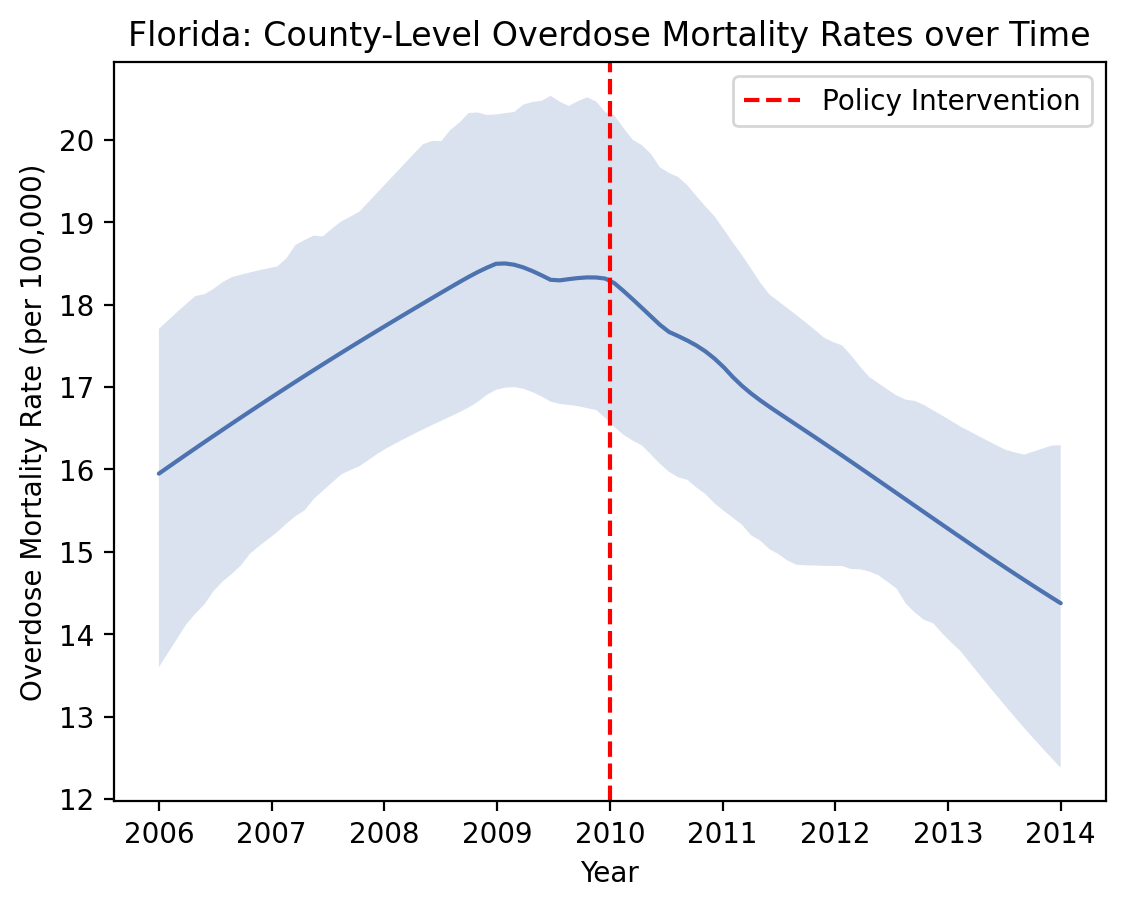

In [367]:
import seaborn.objects as so
import seaborn_objects_recipes as sor
import matplotlib.pyplot as plt

florida_counties = pop_overdose_merged_sel_counties[
    pop_overdose_merged_sel_counties["STNAME"] == "Florida"
]

fig, ax = plt.subplots()
plot = (
    so.Plot(florida_counties, x="Year", y="County_Mortality_Rate")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
    .label(
        x="Year",
        y="Overdose Mortality Rate (per 100,000)",
        title="Lowess Plot with Confidence Intervals",
    )
)
plot.on(ax).plot()
ax.axvline(x=2010, color="red", linestyle="--", label="Policy Intervention")
ax.set_facecolor("white")
ax.set_title("Florida: County-Level Overdose Mortality Rates over Time")
ax.legend()
fig.savefig("florida_pp2.png")
plt.show()

DiD:

Plotting overdose mortality rate of Florida & control states from 2006 to 2014:

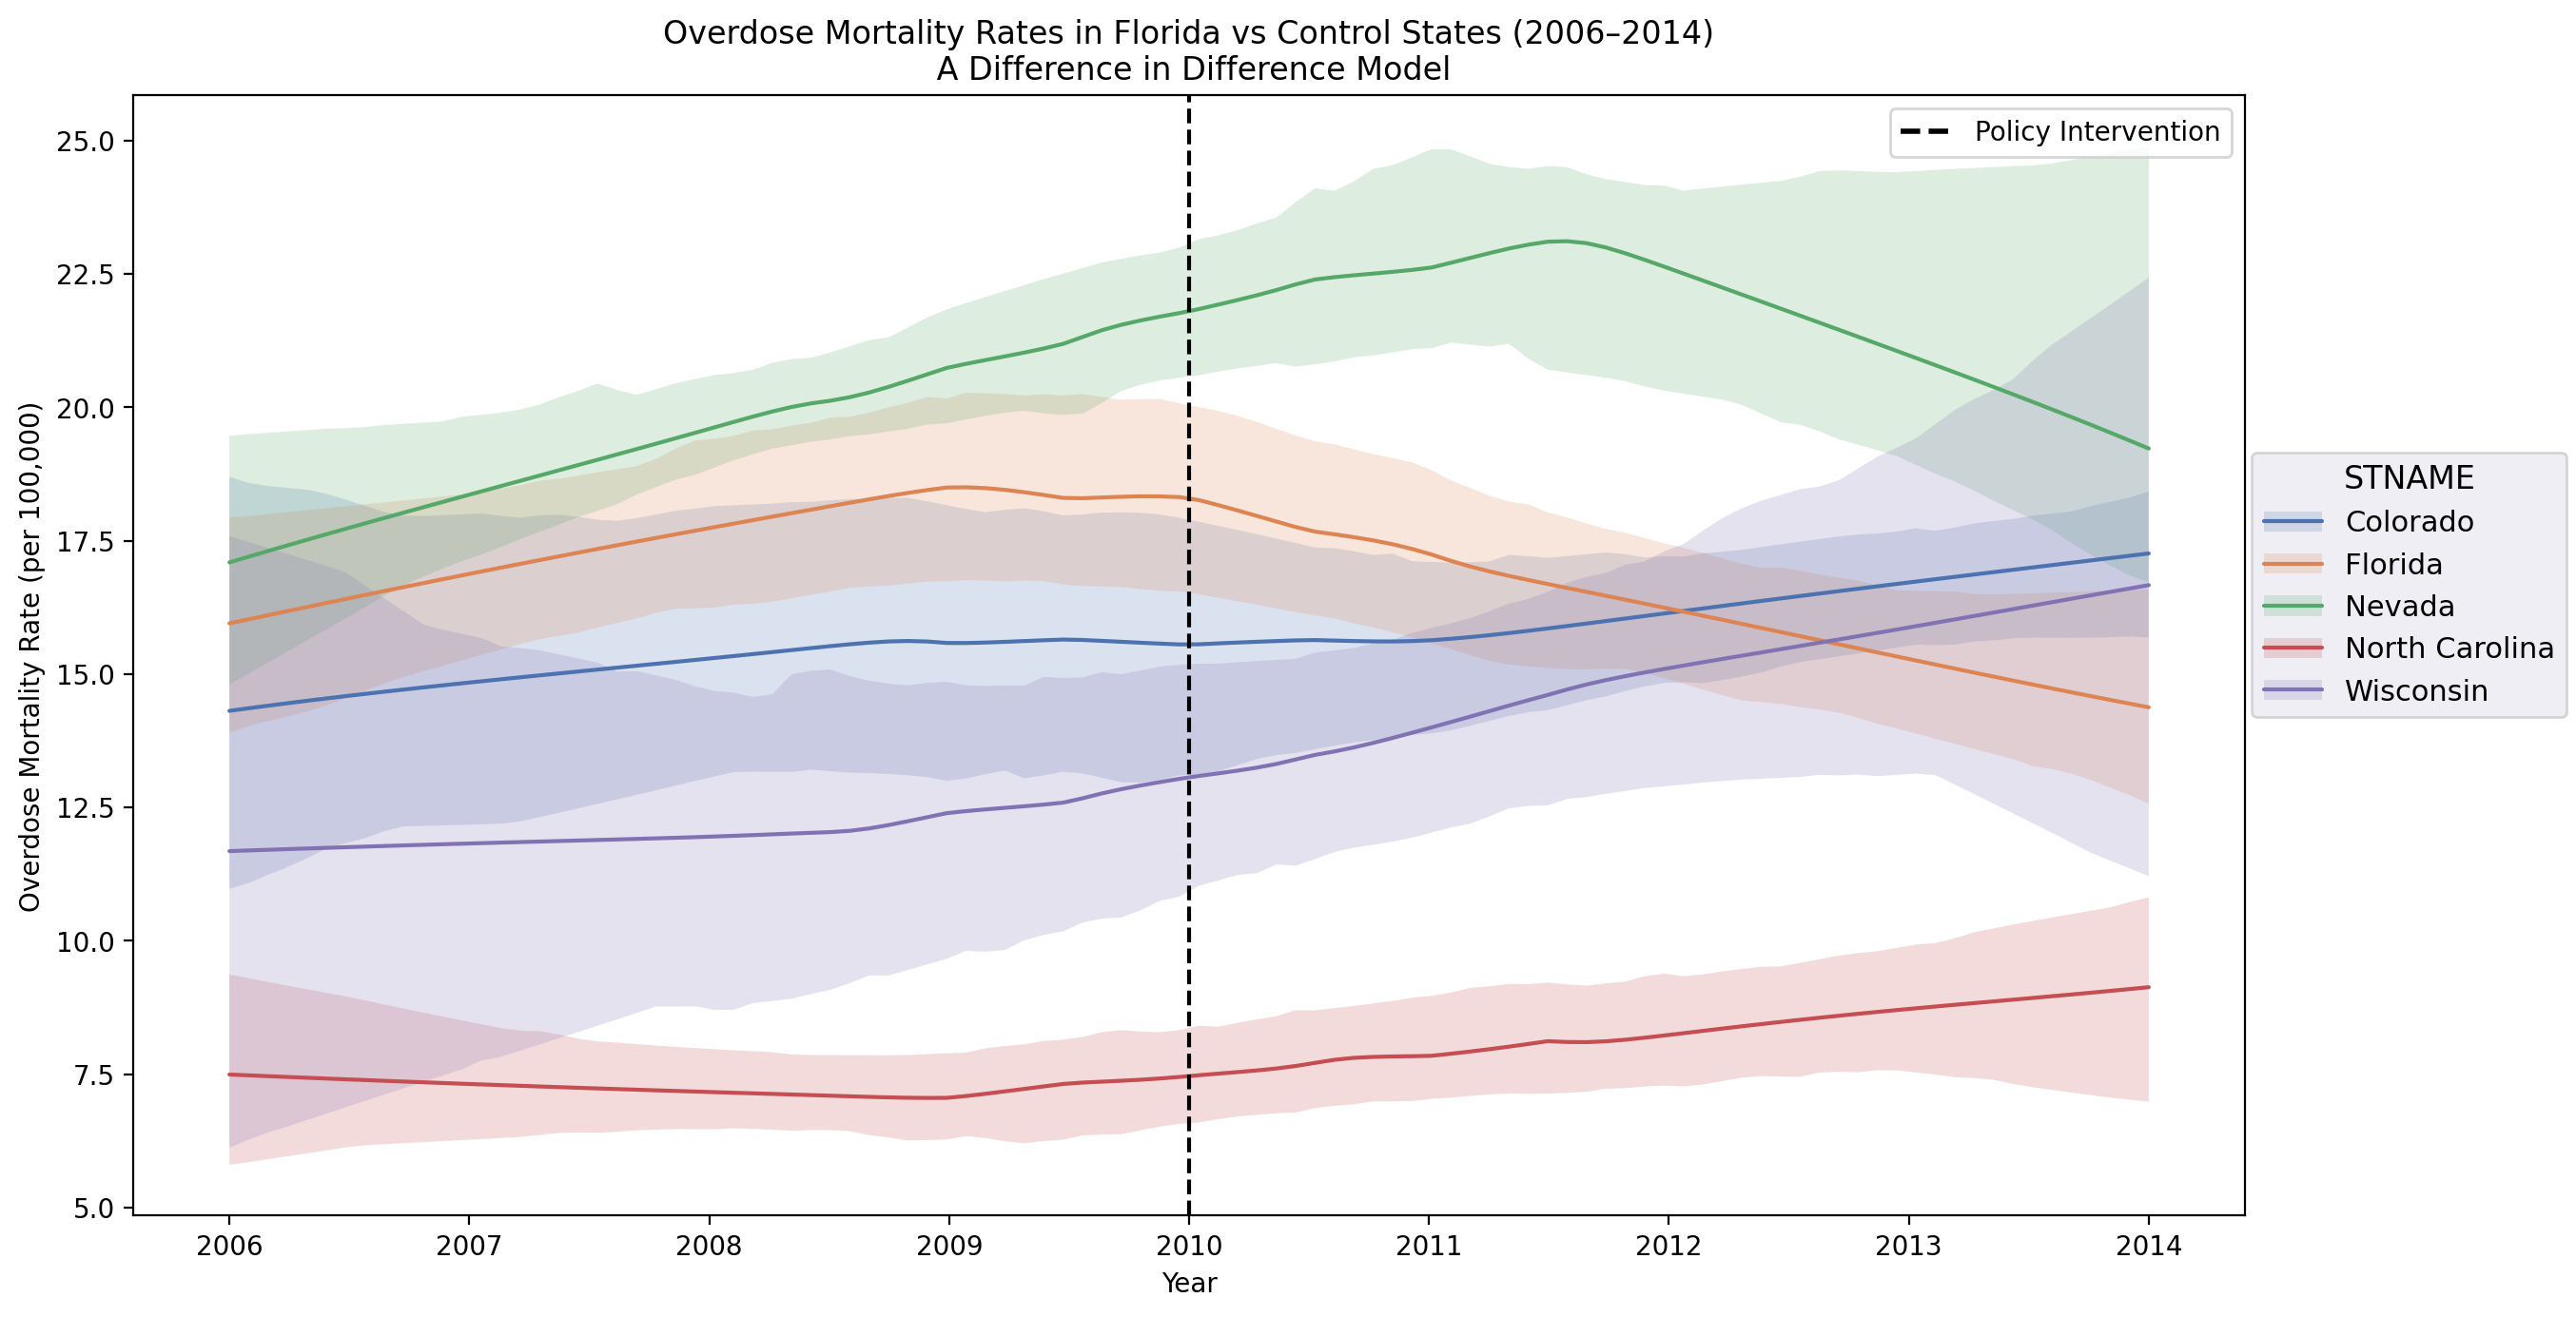

In [368]:
import seaborn.objects as so
import seaborn_objects_recipes as sor
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

lowess = sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95)

fig, ax = plt.subplots(figsize=(12, 7))

(
    so.Plot(
        pop_overdose_merged_sel_counties,
        x="Year",
        y="County_Mortality_Rate",
        color="STNAME",
    )
    .add(so.Line(), lowess)  # smoothed lines
    .add(so.Band(), lowess)  # CI bands
    .on(ax)
    .plot()
)

# Policy line
ax.axvline(2010, color="black", linestyle="--")

ax.set_title(
    "Overdose Mortality Rates in Florida vs Control States (2006–2014)\n A Difference in Difference Model"
)
ax.set_xlabel("Year")
ax.set_ylabel("Overdose Mortality Rate (per 100,000)")

handles, labels = ax.get_legend_handles_labels()

handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=2))
labels.append("Policy Intervention")

ax.legend(handles=handles, labels=labels, loc="upper right")

plt.tight_layout()

fig.savefig("overdose_mortality_DID.png", bbox_inches="tight")